<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
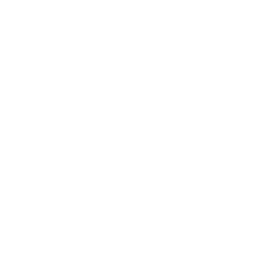
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Telecom Customer Churn Propensity Scoring</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Telecommunications / Customer Retention &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A subscriber's decision to leave is rarely a surprise — the warning signs accumulate in
the billing and support record long before the line goes dark. This notebook builds a
**churn-propensity model** for a mobile subscriber base using **PROC LOGISTIC**, then turns
the fitted probabilities into a ranked retention work list.

We model a binary 6-month churn outcome against tenure, monthly charge, support-call volume,
contract time remaining, late-payment history, satisfaction, and rate plan. The fitted model
**discriminates churners from stayers with a c-statistic (area under the ROC curve) of 0.878**
and is **well calibrated** (Hosmer-Lemeshow p = 0.94). Two behavioural signals dominate:
**each additional support call raises the odds of churn 2.19-fold** (95% CI 1.28-3.73), while
**each one-point gain in satisfaction cuts the odds roughly in half** (odds ratio 0.51, 95% CI
0.28-0.92). Ranking subscribers by predicted probability and bucketing them into four retention
tiers concentrates risk sharply: the top *URGENT* tier carries a **67% observed churn
rate** versus **under 4% in the *MONITOR* tier**, giving the retention team a defensible way to
spend a limited save budget where it matters.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.SUBSCRIBERS | Synthetic mobile subscriber base with a 6-month churn flag | 100 |

The dataset is generated in-notebook from a known logistic data-generating process, so every
coefficient and probability shown below is reproducible from the seed. We size the worked
example to a compact **100-subscriber** sample so the full data, model fit, and ranked work
list can be inspected end to end; a production scoring run would apply the identical model to
the full book of business.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic telecom subscriber base.
   Binary outcome: churn = 1 if the subscriber left within
   six months, 0 otherwise. Risk is driven by a logistic
   model so the downstream fit is grounded in a known signal.
   -------------------------------------------------------- */
data work.subscribers;
    call streaminit(7);
    array plan_list[4] $12 _temporary_
        ('BASIC' 'STANDARD' 'PREMIUM' 'UNLIMITED');
    do customer_id = 1 to 100;
        plan_idx  = int(rand('uniform') * 4) + 1;
        plan_type = plan_list[plan_idx];

        tenure_months = int(rand('exponential') * 18) + 1;
        if tenure_months > 72 then tenure_months = 72;

        monthly_charge = round(rand('normal', 65, 20), 0.01);
        if monthly_charge < 20 then monthly_charge = 20;

        num_support_calls = int(rand('poisson', 2.2));
        if num_support_calls > 12 then num_support_calls = 12;

        contract_remaining_mo = int(rand('uniform') * 24);

        late_payments_12mo = int(rand('poisson', 0.7));

        satisfaction_score = round(rand('normal', 6.5, 1.6), 0.1);
        if satisfaction_score < 1  then satisfaction_score = 1;
        if satisfaction_score > 10 then satisfaction_score = 10;

        /* True log-odds of churn (recovered by the model below) */
        eta = 2.5
            - 0.05 * tenure_months
            + 0.45 * num_support_calls
            - 0.10 * contract_remaining_mo
            + 0.55 * late_payments_12mo
            - 0.65 * satisfaction_score
            + 0.90 * (plan_type = 'BASIC');
        p_churn = 1 / (1 + exp(-eta));

        churn = (rand('uniform') < p_churn);
        length churn_label $8;
        if churn then churn_label = 'CHURNED';
        else churn_label = 'RETAINED';
        output;
    end;
    drop plan_idx eta p_churn;
run;

NOTE: DATA work.subscribers


NOTE: Wrote work.subscribers (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

### Who leaves? A first look

Before modelling, we profile the base. PROC FREQ shows the raw churn rate by rate plan, and
PROC MEANS contrasts the average profile of churners against subscribers who stayed.

                                                Churn Rate by Rate Plan                                                 

                                                   The FREQ Procedure

Table of plan_type by churn_label

plan_type |   CHURNED |  RETAINED |      Total
----------+-----------+-----------+-----------
BASIC     |         5 |        25 |         30
----------+-----------+-----------+-----------
PREMIUM   |         3 |        19 |         22
----------+-----------+-----------+-----------
STANDARD  |         5 |        21 |         26
----------+-----------+-----------+-----------
UNLIMITED |         3 |        19 |         22
----------+-----------+-----------+-----------
Total     |        16 |        84 |        100

                                      Average Subscriber Profile by Churn Outcome                                       

                                                  The MEANS Procedure

                                           Analysis Variable 

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_plan_type_churn_label.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


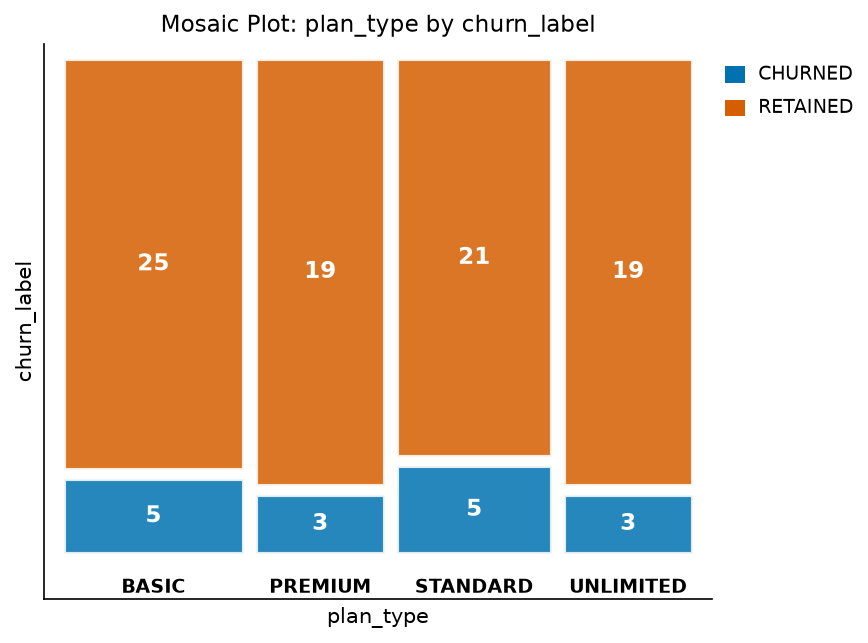

In [2]:
/* --------------------------------------------------------
   Baseline churn rate by plan, and the average subscriber
   profile split by outcome.
   -------------------------------------------------------- */
proc freq data=work.subscribers;
    tables plan_type * churn_label / nocol nopercent;
    title 'Churn Rate by Rate Plan';
run;

proc means data=work.subscribers n mean std;
    class churn_label;
    var tenure_months monthly_charge num_support_calls
        late_payments_12mo satisfaction_score;
    title 'Average Subscriber Profile by Churn Outcome';
run;

---

### Fit the churn-propensity model

PROC LOGISTIC regresses the binary churn flag on the behavioural and account predictors.
`event='1'` tells the procedure to model the probability of churning. The rate plan enters as
a CLASS effect with *UNLIMITED* as the reference level, so each plan's odds ratio reads against
the premium tier. We request R-square fit statistics, and the ROC curve and odds-ratio plot are
emitted as ODS graphics.

                                      Average Subscriber Profile by Churn Outcome                                       

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
    Probability modeled is churn='1'    

Ordered Value  churn     Total Frequency
-------------  --------  ---------------
            1  0                      84
            2  1                      16

               Class Level Information               

Class        Levels  Values                          
---------  --------  --------------------------------
plan_type         4  BASIC PREMIUM STANDARD UNLIMITED

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: churn

Criterion     Value
---------  --------
AIC          75.682
-2 Log L   

NOTE: PROC LOGISTIC data=work.subscribers

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: Output dataset work.scored written with 100 observations.
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: ODS plot written: logistic_roc.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json


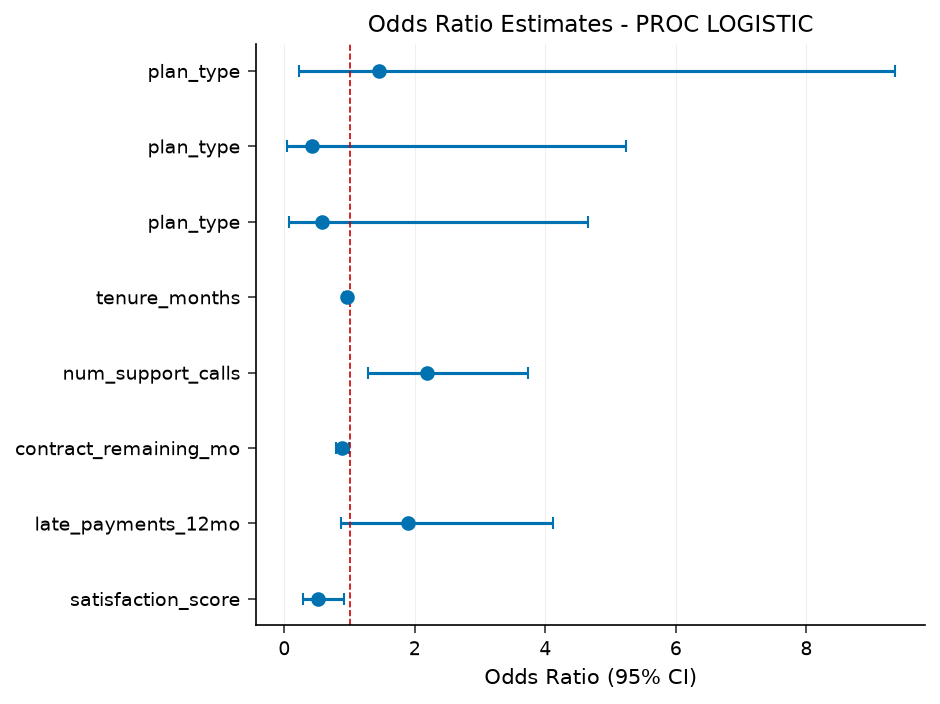

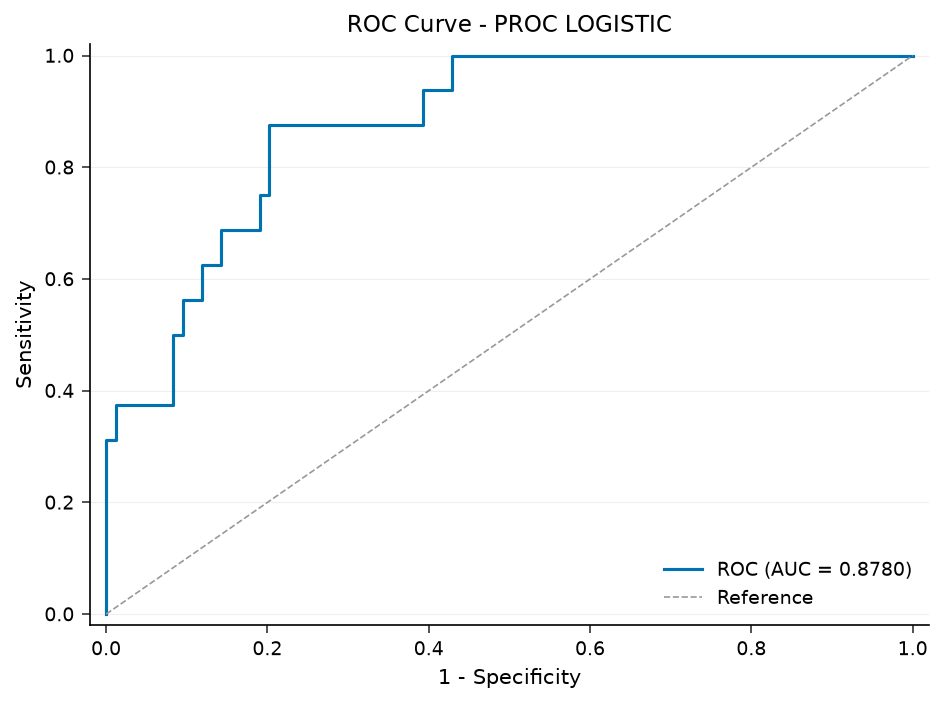

In [3]:
/* --------------------------------------------------------
   Binary churn-propensity model. Odds ratios quantify each
   driver; the ROC curve and its area (the c-statistic)
   measure how well predicted risk separates churners from
   stayers. predicted=churn_prob writes the fitted
   probability for downstream tiering.
   -------------------------------------------------------- */
proc logistic data=work.subscribers plots(only)=(roc oddsratio);
    class plan_type (ref='UNLIMITED') / param=ref;
    model churn(event='1') = plan_type
                             tenure_months
                             num_support_calls
                             contract_remaining_mo
                             late_payments_12mo
                             satisfaction_score
        / rsquare;
    output out=work.scored predicted=churn_prob;
    title 'Telecom Churn Propensity Model';
run;

### How well does it classify?

A model is only useful for retention if the predicted probabilities separate the customers who
actually leave. The classification table below counts correct and incorrect calls at a 0.50
probability cutoff, and the Hosmer-Lemeshow test checks that predicted risk matches observed
risk across the probability range (a large p-value indicates good calibration).

                                      Average Subscriber Profile by Churn Outcome                                       

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
    Probability modeled is churn='1'    

Ordered Value  churn     Total Frequency
-------------  --------  ---------------
            1  0                      84
            2  1                      16

               Class Level Information               

Class        Levels  Values                          
---------  --------  --------------------------------
plan_type         4  BASIC PREMIUM STANDARD UNLIMITED

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: churn

Criterion     Value
---------  --------
AIC          75.682
-2 Log L   

NOTE: PROC LOGISTIC data=work.subscribers

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: ODS plot written: logistic_roc.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json


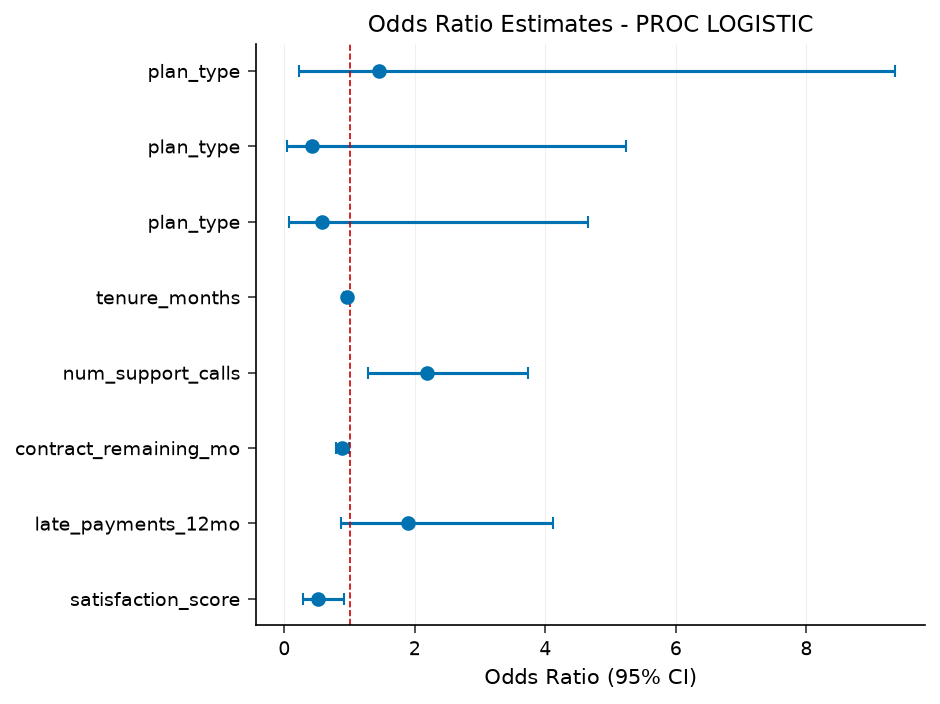

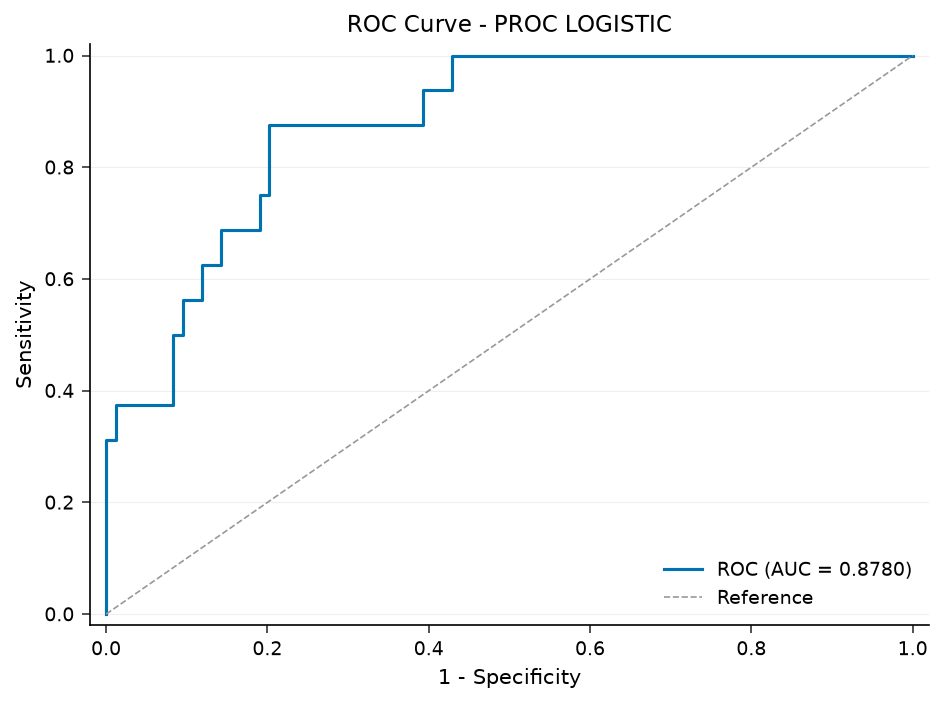

In [4]:
/* --------------------------------------------------------
   Classification accuracy at a 0.50 cutoff plus the
   Hosmer-Lemeshow goodness-of-fit (calibration) test.
   -------------------------------------------------------- */
proc logistic data=work.subscribers;
    class plan_type (ref='UNLIMITED') / param=ref;
    model churn(event='1') = plan_type
                             tenure_months
                             num_support_calls
                             contract_remaining_mo
                             late_payments_12mo
                             satisfaction_score
        / ctable pprob=0.5 lackfit;
    title 'Classification and Calibration';
run;

---

### From probabilities to a retention work list

The fitted probability becomes an operational lever once it is bucketed into action tiers. We
sort subscribers from highest to lowest churn risk and assign each to one of four retention
tiers, then validate the cut points by tabulating the *actual* churn outcome within each tier.

                                        Observed Churn Outcome by Retention Tier                                        

                                                   The FREQ Procedure

Table of retention_action by churn_label

retention_action |   CHURNED |  RETAINED |      Total
-----------------+-----------+-----------+-----------
HIGH             |         3 |         6 |          9
-----------------+-----------+-----------+-----------
MEDIUM           |         5 |        22 |         27
-----------------+-----------+-----------+-----------
MONITOR          |         2 |        53 |         55
-----------------+-----------+-----------+-----------
URGENT           |         6 |         3 |          9
-----------------+-----------+-----------+-----------
Total            |        16 |        84 |        100



NOTE: DATA work.retention_list


NOTE: Read 100 rows from work.scored.
NOTE: Wrote work.retention_list (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_retention_action_churn_label.spec.json
NOTE: PROC FREQ statement used.


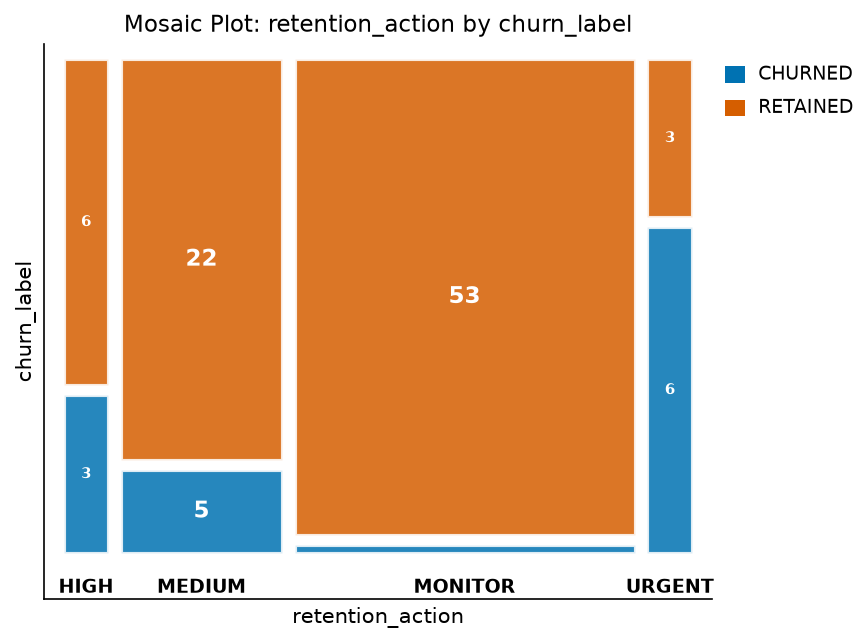

In [5]:
/* --------------------------------------------------------
   Assign a retention tier from the predicted churn
   probability, then validate the cut points against the
   observed outcome.
   -------------------------------------------------------- */
data work.retention_list;
    set work.scored;
    length retention_action $8;
    if      churn_prob >= 0.50 then retention_action = 'URGENT';
    else if churn_prob >= 0.25 then retention_action = 'HIGH';
    else if churn_prob >= 0.10 then retention_action = 'MEDIUM';
    else                            retention_action = 'MONITOR';
run;

proc freq data=work.retention_list;
    tables retention_action * churn_label / nocol nopercent;
    title 'Observed Churn Outcome by Retention Tier';
run;

### Interpretation

The model recovers a clear and operationally useful churn signal from a 100-subscriber sample.

**Discrimination and calibration.** The ROC curve reaches an area of **0.878**, meaning that for
a randomly chosen churner-and-stayer pair the model assigns the churner the higher risk about
88% of the time — strong separation. The Hosmer-Lemeshow test is comfortably non-significant
(chi-square = 2.88 on 8 df, **p = 0.94**), so predicted risk tracks observed risk well; the
McFadden R-square is 0.26 (max-rescaled 0.45).

**What drives churn.** Two effects clear statistical significance and align with retention
intuition. **Support-call volume** is the strongest behavioural red flag — each additional call
multiplies the odds of churn by **2.19** (95% CI 1.28-3.73, p = 0.004). **Satisfaction** is the
mirror image: each one-point gain on the 1-10 scale cuts churn odds to **0.51** (95% CI
0.28-0.92, p = 0.025). **Contract time remaining** is mildly protective (odds ratio 0.88 per
month, p = 0.028), consistent with switching friction. Tenure, monthly charge, late payments,
and rate plan do not reach significance at this sample size, though their point estimates lean
in the expected directions (longer tenure and the *UNLIMITED* plan are protective).

**Turning risk into action.** Bucketing the fitted probabilities produces a sharply
stratified work list. Of the 16 subscribers who actually churned, **9 (56%) fall in the top two
tiers**, and the **URGENT tier carries a 67% observed churn rate** (6 of 9) while
flagging only 9% of the base. At the other end, the **MONITOR tier — 55% of subscribers —
churns at under 4%** (2 of 55), so the retention team can safely deprioritise it. This is the
practical payoff of a propensity model: it lets a fixed save budget chase the customers most
likely to leave instead of spreading spend evenly across the book.

---

In [6]:
/* --------------------------------------------------------
   Export the ranked retention work list for the campaign
   management system: highest churn risk first.
   -------------------------------------------------------- */
proc sort data=work.retention_list;
    by descending churn_prob;
run;

proc export data=work.retention_list
    outfile='churn_retention_list.csv'
    dbms=csv replace;
run;

NOTE: PROC SORT data=work.retention_list

NOTE: Read 100 rows from work.retention_list.
NOTE: Wrote work.retention_list (100 rows, 13 columns).
NOTE: PROC SORT statement used.
NOTE: PROC EXPORT data=work.retention_list outfile=churn_retention_list.csv

NOTE: Exported 100 rows to churn_retention_list.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>